In [1]:
# =========================================
# Rain Tomorrow (Australia) — Analysis (EDA)
# Notebook: 3. Analysis/01_eda_plots.ipynb
# Inputs : ../1. Data/processed/weatherAUS_eda_ready.csv
# Outputs: ./figures/*.png
# =========================================

In [2]:
# Imports & Global settings
import warnings
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.simplefilter("ignore", category=FutureWarning)
warnings.simplefilter("ignore", category=UserWarning)
pd.set_option("display.max_columns", None)

In [3]:
# Theme (match presentation)
BG_COLOR = "#E6DED2"
TEXT_COLOR = "#2B2B2B"
sns.set_theme(style="whitegrid", palette="crest")
plt.rcParams["figure.facecolor"] = BG_COLOR
plt.rcParams["axes.facecolor"] = BG_COLOR
plt.rcParams["savefig.facecolor"] = BG_COLOR
plt.rcParams["text.color"] = TEXT_COLOR
plt.rcParams["axes.labelcolor"] = TEXT_COLOR
plt.rcParams["xtick.color"] = TEXT_COLOR
plt.rcParams["ytick.color"] = TEXT_COLOR
plt.rcParams["grid.alpha"] = 0.15

In [4]:
# Paths
EDA_PATH = Path("../1. Data/processed/weatherAUS_eda_ready.csv")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

def save_fig(filename: str):
    """
    Save current Matplotlib figure with consistent background.
    """
    out_path = FIG_DIR / filename
    plt.savefig(out_path, dpi=220, bbox_inches="tight", facecolor=plt.gcf().get_facecolor())

In [6]:
# Load EDA-ready dataset
df = pd.read_csv(EDA_PATH, low_memory=False)
print("EDA data shape:", df.shape)
df.head()

EDA data shape: (142193, 30)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Month,WindSpeed,Humidity,Pressure,Cloud,Temperature,RainTomorrow_bin
0,2008-07-01,Adelaide,8.8,15.7,5.0,1.600000,2.6,NW,48.0,SW,W,13.0,15.0,92.0,67.0,1017.4,1017.7,7.0,5.0,13.5,14.9,Yes,No,Jul,14.0,79.5,1017.55,6.0,14.20,0
1,2008-07-02,Adelaide,12.7,15.8,0.8,1.400000,7.8,SW,35.0,SSW,SW,13.0,15.0,75.0,52.0,1022.4,1022.6,7.0,5.0,13.7,15.5,No,No,Jul,14.0,63.5,1022.50,6.0,14.60,0
2,2008-07-03,Adelaide,6.2,15.1,0.0,1.800000,2.1,W,20.0,NNE,SW,2.0,11.0,81.0,56.0,1027.8,1026.5,7.0,5.0,9.3,13.9,No,No,Jul,6.5,68.5,1027.15,6.0,11.60,0
3,2008-07-04,Adelaide,5.3,15.9,0.0,1.400000,8.0,NNE,30.0,NNE,NE,6.0,13.0,71.0,46.0,1028.7,1025.6,7.0,5.0,10.2,15.3,No,No,Jul,9.5,58.5,1027.15,6.0,12.75,0
4,2008-07-06,Adelaide,11.3,15.7,NaN,3.533333,1.5,NNW,52.0,NNE,NNW,15.0,22.0,62.0,62.0,1019.5,1016.2,7.0,5.0,13.0,14.4,NaN,Yes,Jul,18.5,62.0,1017.85,6.0,13.70,1


In [7]:
# Basic EDA prep
# Target: create binary + readable label for plots
df = df.dropna(subset=["RainTomorrow"]).copy()

# Handle both cases: RainTomorrow already 0/1 OR is "Yes"/"No"
if df["RainTomorrow"].dtype.kind in "biufc":
    df["RainTomorrow_bin"] = df["RainTomorrow"].astype(int)
else:
    df["RainTomorrow_bin"] = df["RainTomorrow"].map({"No": 0, "Yes": 1}).astype(int)
df["RainTomorrow_label"] = df["RainTomorrow_bin"].map({0: "No Rain", 1: "Rain"})

# Ensure Month has a sensible order (if Month exists)
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
if "Month" in df.columns:
    df["Month"] = pd.Categorical(df["Month"], categories=month_order, ordered=True)

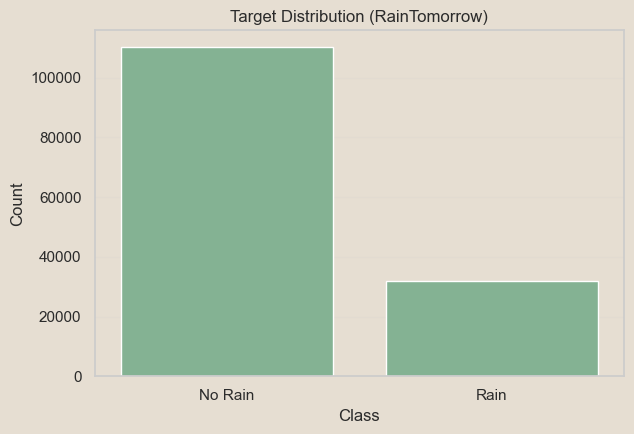

In [8]:
# Plot 01 — Target distribution (imbalance)
plt.figure(figsize=(6.5, 4.5))
ax = sns.countplot(data=df, x="RainTomorrow_label", order=["No Rain", "Rain"])
ax.set_title("Target Distribution (RainTomorrow)")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
plt.tight_layout()
save_fig("01_target_distribution.png")
plt.show()

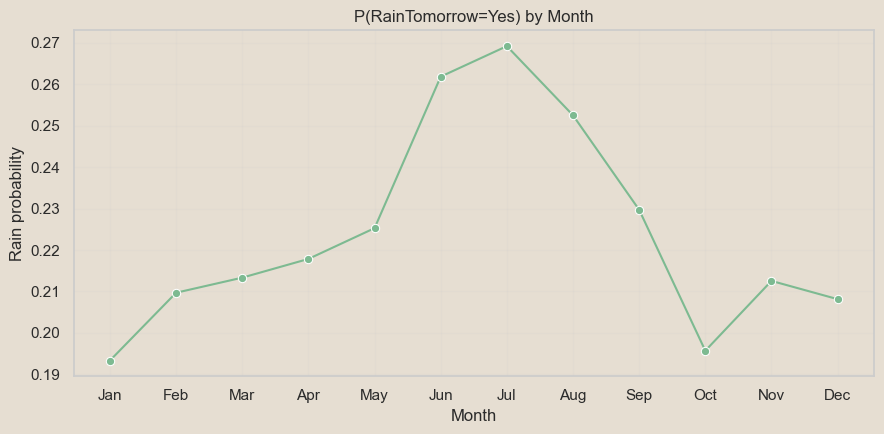

In [9]:
# Plot 02 — P(RainTomorrow=Yes) by Month (seasonality)
month_risk = (df.groupby("Month", observed=False)["RainTomorrow_bin"].mean().reset_index(name="rain_rate"))

plt.figure(figsize=(9, 4.5))
ax = sns.lineplot(data=month_risk, x="Month", y="rain_rate", marker="o")
ax.set_title("P(RainTomorrow=Yes) by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Rain probability")
plt.tight_layout()
save_fig("02_rain_rate_by_month.png")
plt.show()

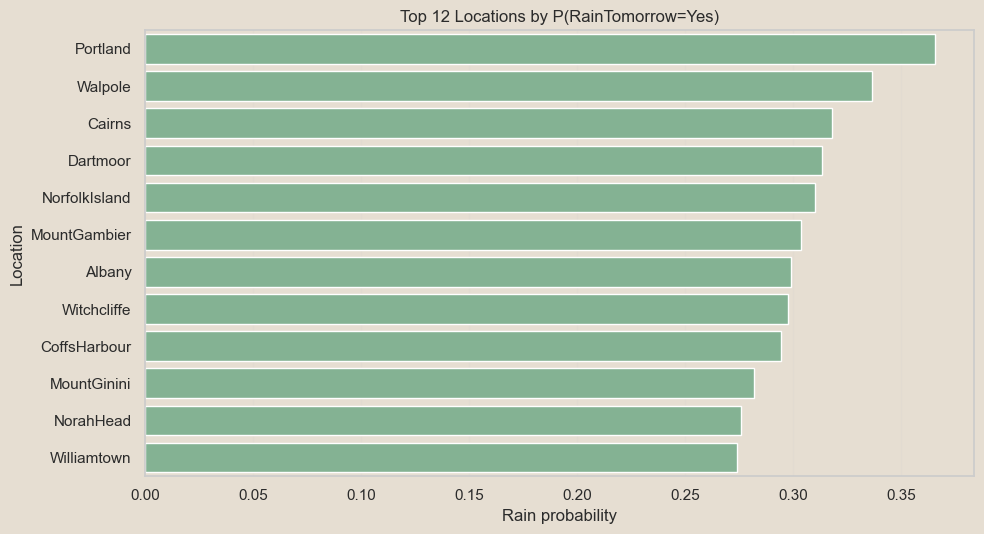

In [11]:
# Plot 03 — Top 12 Locations by rain probability
loc_risk = (df.groupby("Location", observed=False)["RainTomorrow_bin"].mean().sort_values(ascending=False).head(12).reset_index(name="rain_rate"))

plt.figure(figsize=(10, 5.5))
ax = sns.barplot(data=loc_risk, x="rain_rate", y="Location")
ax.set_title("Top 12 Locations by P(RainTomorrow=Yes)")
ax.set_xlabel("Rain probability")
ax.set_ylabel("Location")
plt.tight_layout()
save_fig("03_top_locations_rain_rate.png")
plt.show()

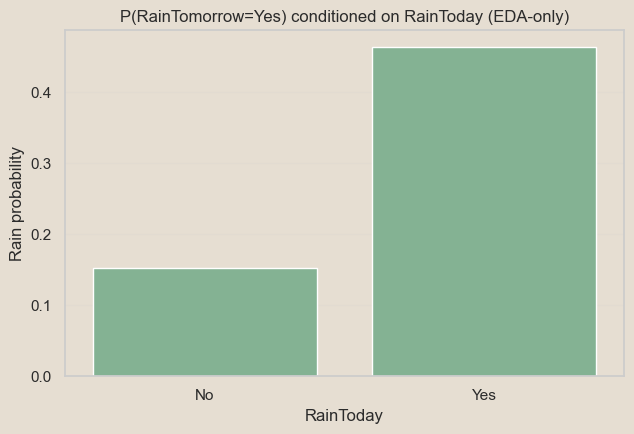

In [13]:
# Plot 04 — RainToday vs RainTomorrow (EDA-only persistence)
df_rt = df.dropna(subset=["RainToday"]).copy()

# Handle both cases: RainToday already 0/1 OR is "Yes"/"No"
if df_rt["RainToday"].dtype.kind in "biufc":
    df_rt["RainToday_bin"] = df_rt["RainToday"].astype(int)
else:
    df_rt["RainToday_bin"] = df_rt["RainToday"].map({"No": 0, "Yes": 1}).astype(int)

rt_risk = (df_rt.groupby("RainToday_bin")["RainTomorrow_bin"].mean().reset_index(name="rain_rate"))
rt_risk["RainToday_label"] = rt_risk["RainToday_bin"].map({0: "No", 1: "Yes"})

plt.figure(figsize=(6.5, 4.5))
ax = sns.barplot(data=rt_risk, x="RainToday_label", y="rain_rate", order=["No", "Yes"])
ax.set_title("P(RainTomorrow=Yes) conditioned on RainToday (EDA-only)")
ax.set_xlabel("RainToday")
ax.set_ylabel("Rain probability")
plt.tight_layout()
save_fig("04_rainToday_vs_rainTomorrow.png")
plt.show()

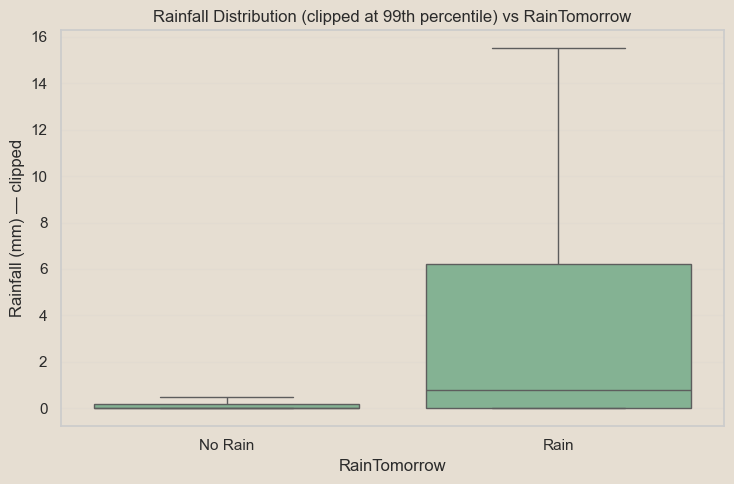

In [15]:
# Plot 05 — Rainfall distribution vs target
df_rf = df.dropna(subset=["Rainfall"]).copy()

# Clip only for visualization (avoid extreme outliers dominating the plot)
q99 = df_rf["Rainfall"].quantile(0.99)
df_rf["Rainfall_clip"] = df_rf["Rainfall"].clip(upper=q99)

plt.figure(figsize=(7.5, 5))
ax = sns.boxplot(data=df_rf, x="RainTomorrow_label", y="Rainfall_clip", order=["No Rain", "Rain"], showfliers=False)
ax.set_title("Rainfall Distribution (clipped at 99th percentile) vs RainTomorrow")
ax.set_xlabel("RainTomorrow")
ax.set_ylabel("Rainfall (mm) — clipped")
plt.tight_layout()
save_fig("05_rainfall_distribution.png")
plt.show()

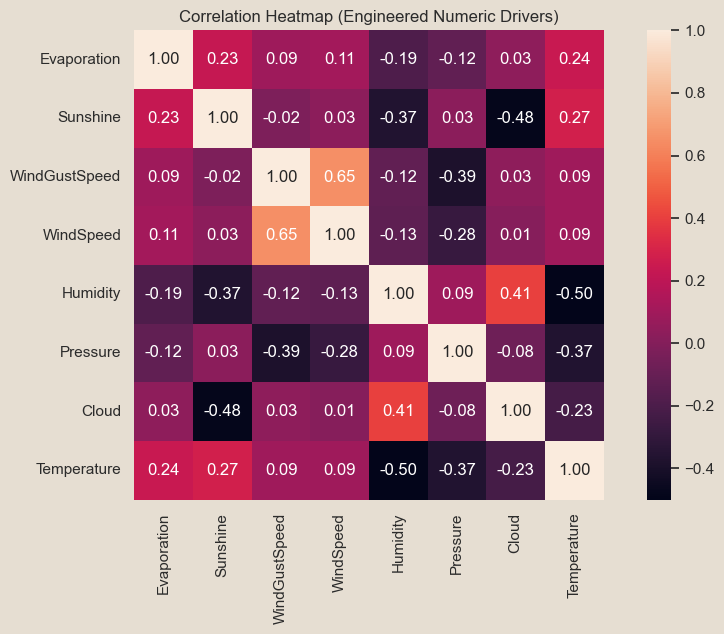

In [16]:
# Plot 06 — Correlation heatmap 
drivers = ["Evaporation", "Sunshine", "WindGustSpeed", "WindSpeed", "Humidity", "Pressure", "Cloud", "Temperature"]
drivers_present = [c for c in drivers if c in df.columns]
corr = df[drivers_present].corr(numeric_only=True)

plt.figure(figsize=(9.5, 6.5))
ax = sns.heatmap(corr, annot=True, fmt=".2f", square=True)
ax.set_title("Correlation Heatmap (Engineered Numeric Drivers)")
plt.tight_layout()
save_fig("06_corr_heatmap_drivers.png")
plt.show()

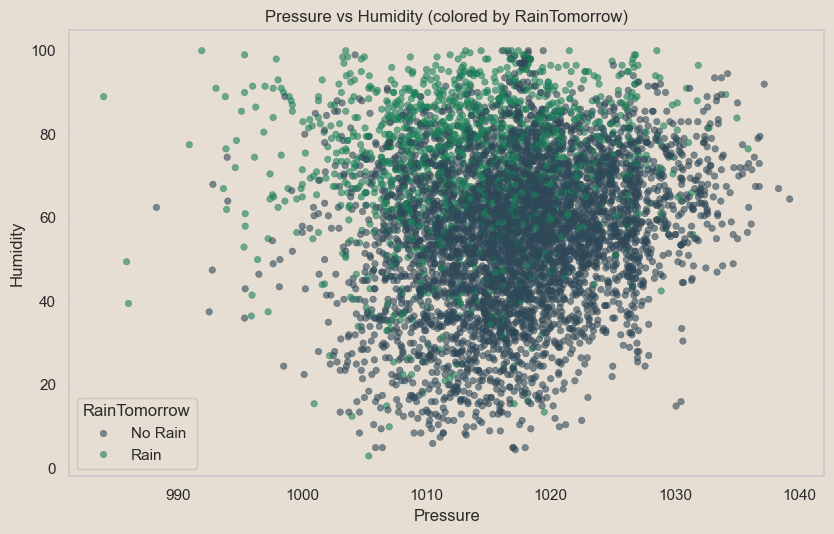

In [ ]:
# Plot 07 — Scatter: Pressure vs Humidity (colored by target)
df_scatter = df.dropna(subset=["Pressure", "Humidity"]).sample(n=min(6000, len(df.dropna(subset=["Pressure", "Humidity"]))), random_state=42)

plt.figure(figsize=(8.5, 5.5))
palette_scatter = {
    "No Rain": "#2F4858",
    "Rain": "#1B7F5A"}

ax = sns.scatterplot(
    data=df_scatter,
    x="Pressure",
    y="Humidity",
    hue="RainTomorrow_label",
    palette=palette_scatter,
    alpha=0.6,              
    s=22,                   
    edgecolor=None)
ax.set_title("Pressure vs Humidity (colored by RainTomorrow)")
ax.set_xlabel("Pressure")
ax.set_ylabel("Humidity")
leg = plt.legend(title="RainTomorrow", loc="lower left", frameon=True)
leg.get_frame().set_facecolor(BG_COLOR)
leg.get_frame().set_edgecolor("#C9BFAF")
plt.tight_layout()
save_fig("07_scatter_pressure_vs_humidity.png")
plt.show()

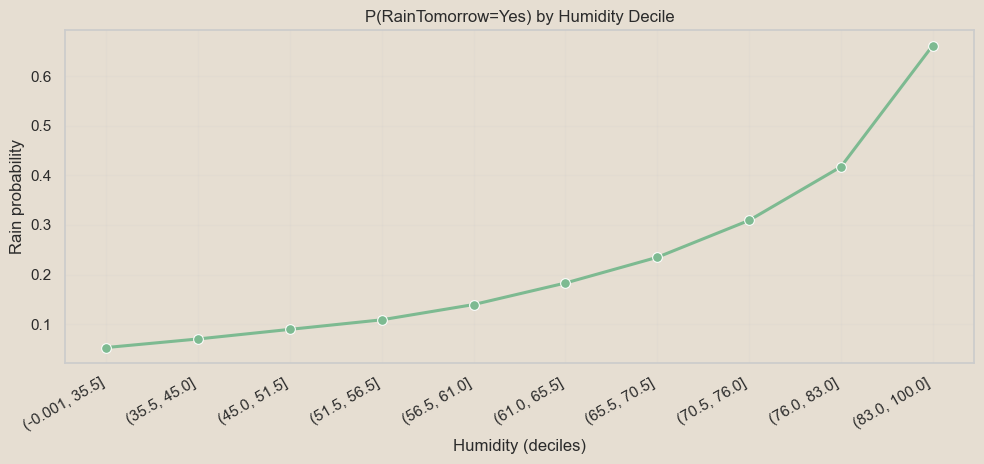

In [28]:
# Plot 08 — Rain rate by Humidity deciles (monotonic relationship check)
df_h = df.dropna(subset=["Humidity"]).copy()

df_h["Humidity_decile"] = pd.qcut(df_h["Humidity"], q=10, duplicates="drop")
hum_risk = (df_h.groupby("Humidity_decile", observed=False)["RainTomorrow_bin"].mean().reset_index(name="rain_rate"))
hum_risk["decile_id"] = hum_risk["Humidity_decile"].cat.codes + 1
hum_risk = hum_risk.sort_values("decile_id").reset_index(drop=True)
hum_risk["decile_label"] = hum_risk["Humidity_decile"].astype(str)

plt.figure(figsize=(10, 4.8), facecolor=BG_COLOR)
ax = plt.gca()
ax.set_facecolor(BG_COLOR)
sns.lineplot(
    data=hum_risk,
    x="decile_id",
    y="rain_rate",
    marker="o",
    linewidth=2.2,
    markersize=7)
ax.set_title("P(RainTomorrow=Yes) by Humidity Decile")
ax.set_xlabel("Humidity (deciles)")
ax.set_ylabel("Rain probability")
ax.set_xticks(hum_risk["decile_id"])
ax.set_xticklabels(hum_risk["decile_label"], rotation=30, ha="right")
ax.grid(True, alpha=0.15)
plt.tight_layout()
save_fig("08_rain_rate_by_humidity_decile.png")
plt.show()

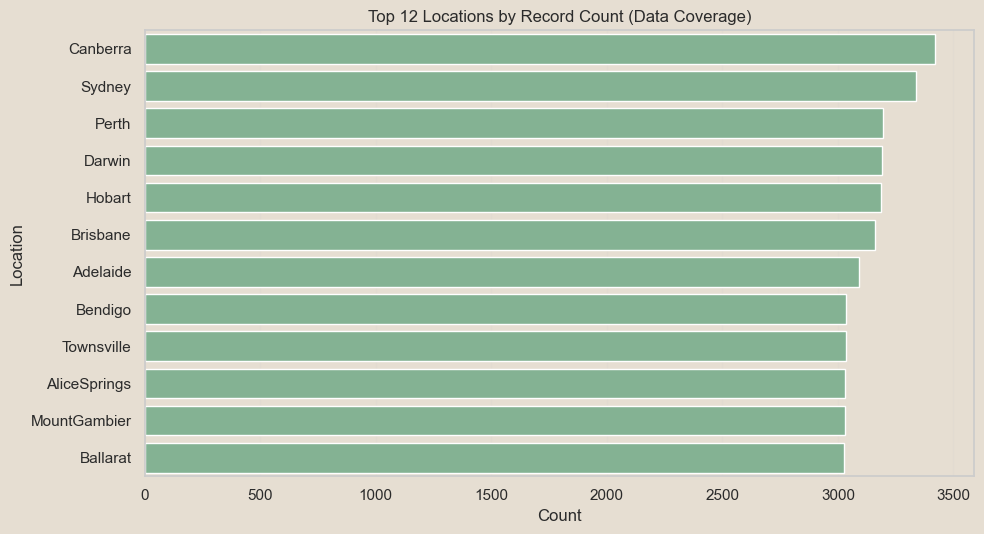

In [19]:
# Plot 09 — Top 12 Locations by record count (coverage)
loc_count = df["Location"].value_counts().head(12).reset_index()
loc_count.columns = ["Location", "count"]

plt.figure(figsize=(10, 5.5))
ax = sns.barplot(data=loc_count, x="count", y="Location")
ax.set_title("Top 12 Locations by Record Count (Data Coverage)")
ax.set_xlabel("Count")
ax.set_ylabel("Location")
plt.tight_layout()
save_fig("09_top_locations_count.png")
plt.show()

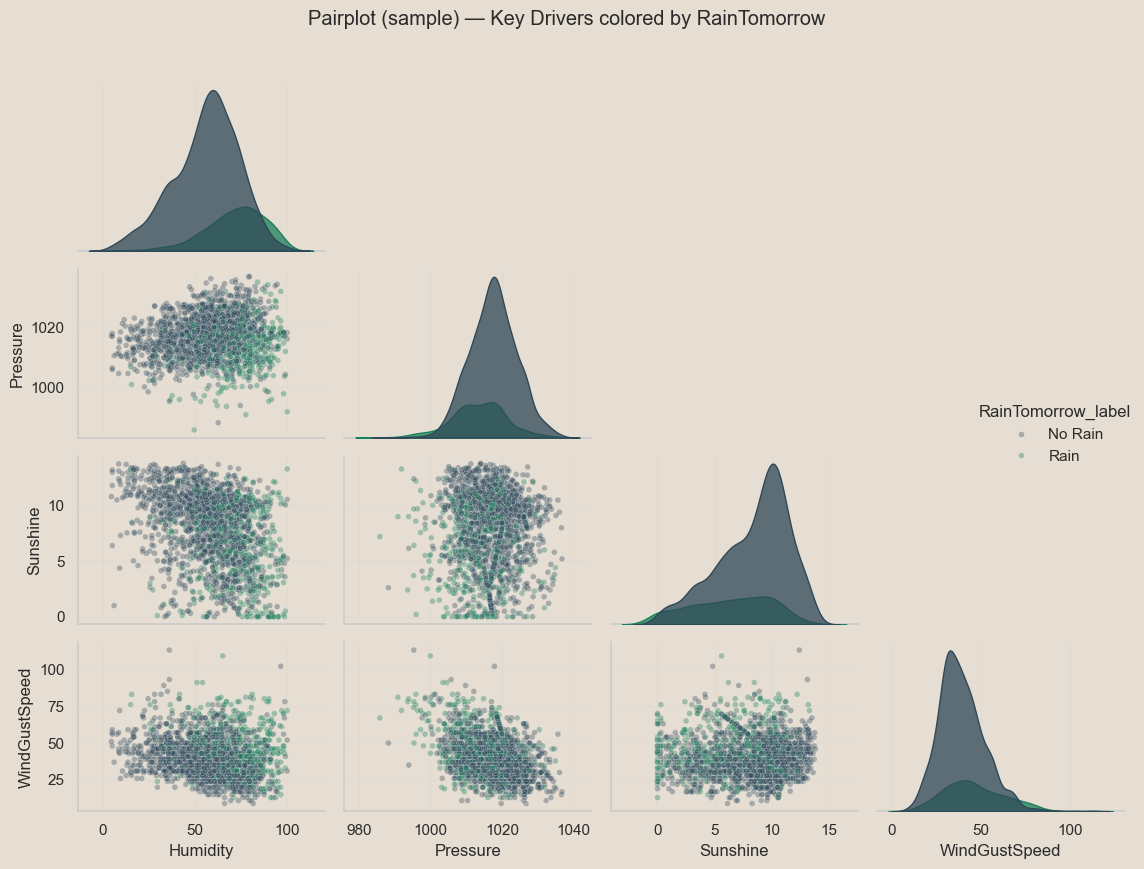

In [27]:
# Plot 10 — Pairplot (sample) for key drivers (correlation + separation)
pair_cols = [c for c in ["Humidity", "Pressure", "Sunshine", "WindGustSpeed"] if c in df.columns]
df_pair = df.dropna(subset=pair_cols).copy()
df_pair = df_pair.sample(n=min(2000, len(df_pair)), random_state=42)

g = sns.pairplot(
    df_pair,
    vars=pair_cols,
    hue="RainTomorrow_label",
    corner=True,
    palette=palette_scatter,
    plot_kws={"alpha": 0.35, "s": 18},
    diag_kws={"alpha": 0.75})

g.figure.set_facecolor(BG_COLOR)
for ax in g.axes.flatten():
    if ax is not None:
        ax.set_facecolor(BG_COLOR)
g.figure.suptitle("Pairplot (sample) — Key Drivers colored by RainTomorrow", y=1.02)
g.figure.set_size_inches(11.5, 8.5)
g.figure.tight_layout()
save_fig("10_pairplot_drivers.png")
plt.show()

In [ ]:
print("Done. Exported plots to:", FIG_DIR.resolve())